### Planning a telescope observation

You want to know how likely it is that tomorrow night will be clear given the weather tonight (clear or cloudy). The weather tomorrow depends on the weather today. From past history, you know that:

$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$

which means that

$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$

We also have

$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$

which means that

$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$


- We can start with the sky conditions today and make predictions going forward more and more into the future.
- This will look like a big decision tree. 
- After enough days, we'll reach equilibrium probabilities that have to do with the mean weather statistics (ignoring seasons) and we'll arrive at

$$p({\rm clear}) = 0.83,$$

and 

$$p({\rm cloudy}) = 0.17.$$


#### Tasks

- Start off on a cloud day. 
- Implement your weather forecast based on the above probabilities
- Run your simulator for N days (with $N\gtrsim 10^4$)
- Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis. This is called a **trace-plot**, showing how our estimate of $p(\mathrm{clear})$ evolves as the chain samples.  
- Prepare a histogram of the above plot. This reveals the distribution of $p(\mathrm{clear})$.
- Use a summary statistics to determine the most likely value and an error on our estimate.

**Important:** 
- In MCMC the process must be **stationary** which basically means that the chain statistics look the same no matter which chunk you look at, e.g. first half, second half, or every other point, etc.  
- Obviously that isn't going to be the case in the early steps of the chain. In our example above, after some time the process was stationary, but not in the first few days.
- So, there is a **burn-in** phase that needs to be discarded. How one determines the number of early steps to discard as burn-in is tricky, but ***you should always start with a traceplot of your samples!***


#### Tasks

- In the above example, experiment with chopping off different numbers of initial points as burn-in.

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
from scipy.stats import norm
from matplotlib import pyplot as plt
import random
from astroML import stats as statsML

In [2]:
sky = np.array([0, 1]) #Possible sky conditions: Sunny=0 Cloudy=1
cloud_rn = np.array([0.5, 0.5]) #Prob of clear/cloudy sky if today is cloudy 
clear_rn = np.array([0.9, 0.1]) #Prob of clear/cloudy sky if today is clear 
N = 1e5
sunny_days = 0
n_sun = [] #keep track of the number of sunny days 

sky_rn = 1
prev = [] 
prev.append(sky_rn)
n_sun.append(0)
while len(prev) < N:
    if sky_rn == 1:
        sky_rn = np.random.choice(sky, p = cloud_rn)
        prev.append(sky_rn)
        if sky_rn == 0:
            sunny_days +=1
        n_sun.append(sunny_days/len(prev))
    else:
        sky_rn = np.random.choice(sky, p = clear_rn)
        prev.append(sky_rn)
        if sky_rn == 0:
            sunny_days +=1
        n_sun.append(sunny_days/len(prev))

prev = np.array(prev)
n_sun = np.array(n_sun)
days = np.arange(0, N)

Text(0.5, 1.0, 'Trace Plot')

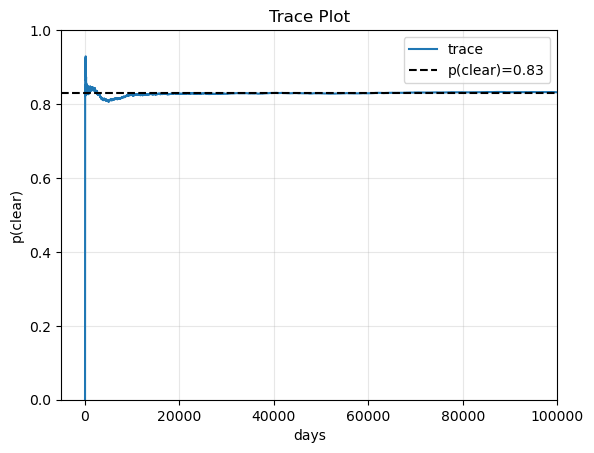

In [3]:
plt.plot(days, n_sun, label = 'trace')
plt.hlines(0.83, -5000, 110000, color = 'k', linestyle = '--', label = 'p(clear)=0.83')
plt.xlabel('days')
plt.ylabel('p(clear)')
plt.grid(alpha = 0.3)
plt.ylim(0, 1.0)
plt.xlim(-5000, 100000)
plt.legend()
plt.title('Trace Plot')

We can see that, after enough days, $p(clear)$ reaches the equilibrum value of 0.83.

Without any cut, our pdf looks like:

Mean = 0.8291
Sigma G = 0.0025


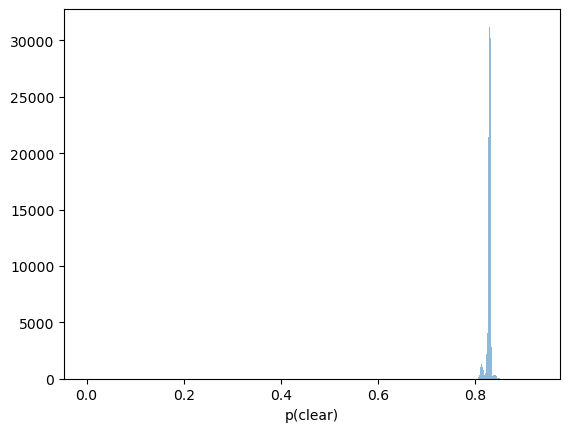

In [10]:
plt.hist(n_sun, bins = 500, alpha = 0.5)
plt.xlabel('p(clear)')
print(f'Mean = {np.mean(n_sun):.4f}')
print(f'Sigma G = {statsML.sigmaG(n_sun):.4f}')

Let's try to experiment with different burn-ins to clear our data:

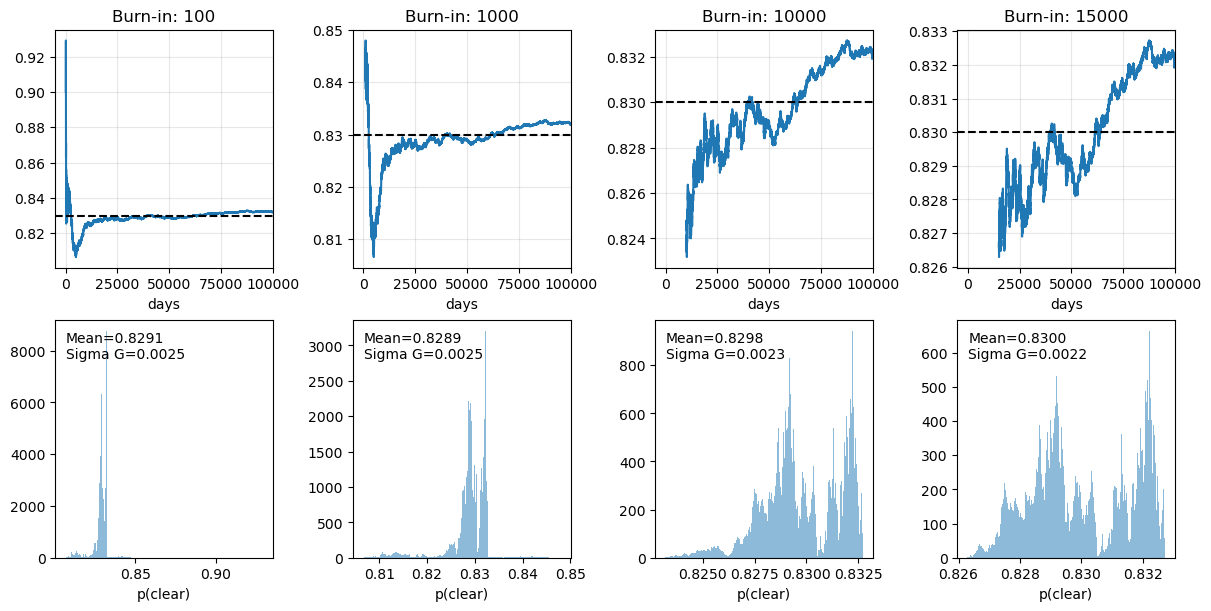

In [11]:
burn_in = [100, 1000, 10000, 15000]

fig, ax = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)
titles = ['Burn-in: 100', 'Burn-in: 1000', 'Burn-in: 10000', 'Burn-in: 15000']

for burn in burn_in:
    ax[0, burn_in.index(burn)].plot(days[burn-1:], n_sun[burn-1:], label = 'trace')
    ax[0, burn_in.index(burn)].hlines(0.83, -5000, 110000, color = 'k', linestyle = '--', label = 'p(clear)=0.83')
    ax[0, burn_in.index(burn)].grid(alpha = 0.3)
    ax[0, burn_in.index(burn)].set_xlim(-5000, 100000)
    ax[0, burn_in.index(burn)].set_title(titles[burn_in.index(burn)])
    ax[0, burn_in.index(burn)].set_xlabel('days')

    ax[1, burn_in.index(burn)].hist(n_sun[burn-1:], bins = 500, alpha = 0.5)
    ax[1, burn_in.index(burn)].text(0.05, 0.95, f'Mean={np.mean(n_sun[burn-1:]):.4f}\nSigma G={statsML.sigmaG(n_sun[burn-1:]):.4f}', transform=ax[1, burn_in.index(burn)].transAxes, verticalalignment='top')
    ax[1, burn_in.index(burn)].set_xlabel('p(clear)')